# 🚀 ĐÁNH GIÁ CHỊU TẢI & HIỆU NĂNG HỆ THỐNG TƯ VẤN SÁCH (BookRAG)
## 🧪 Stress-Test Benchmark on Google Colab — Kế Hoạch NCKH §5.3

**Đề tài:** Hệ Thống Tư Vấn Bán Sách Tự Động Tích Hợp RAG Chống Sai Lệch Thông Tin & Gợi Ý Cá Nhân Hóa  
**Mục tiêu đo lường:**
1. **Baseline Load:** 1 người dùng gửi truy vấn liên tục (mục tiêu: Độ trễ trung bình $< 1.8$s)
2. **Normal Load:** 10 người dùng đồng thời (mục tiêu: P95 $< 2.5$s, tỷ lệ lỗi 0%)
3. **Peak Load:** 30 người dùng đồng thời (mục tiêu: P95 $< 3.0$s, tỷ lệ lỗi $< 1%$)

---

### 📌 Bước 1: Cài đặt thư viện cần thiết trên Google Colab

In [2]:
!pip install -q httpx matplotlib seaborn pandas
print("✅ Đã cài đặt thành công môi trường kiểm thử trên Google Colab!")

✅ Đã cài đặt thành công môi trường kiểm thử trên Google Colab!


### 📌 Bước 2: Cấu hình địa chỉ Endpoint Backend (Target URL)

Để Google Colab có thể gửi request đến máy tính cá nhân đang chạy backend FastAPI (cổng 8000), bạn có thể dùng một trong các cách sau trên máy tính của bạn:

1. **Cách 1 (Khuyên dùng - Nhanh nhất với localtunnel):**
   - Mở PowerShell trên máy tính và gõ:  
     `npx localtunnel --port 8000`  
   - Bạn sẽ nhận được 1 link dạng: `https://xxxx.loca.lt`  
   - Dán link đó kèm `/chat` vào ô bên dưới.

2. **Cách 2 (Dùng ngrok):**
   - Mở terminal gõ: `ngrok http 8000`  
   - Nhận link dạng: `https://xxxx.ngrok-free.app/chat`

3. **Cách 3:** Nhập URL nếu backend đã được deploy lên VPS hoặc cloud (Render, Railway, Cloudflare...)

In [3]:
# @title 🌐 Nhập URL API Endpoint
TARGET_API_URL = "https://nasty-cameras-enjoy.loca.lt/chat" # @param {type:"string"}

print(f"🎯 Endpoint kiểm thử đã cấu hình: {TARGET_API_URL}")

🎯 Endpoint kiểm thử đã cấu hình: https://nasty-cameras-enjoy.loca.lt/chat


### 📌 Bước 3: Nạp kho câu hỏi kiểm thử đa dạng (Test Queries Pool)

In [4]:
SAMPLE_QUERIES = [
    "Tôi nhớ có cuốn sách kể về cậu bé chăn cừu đi tìm kho báu ở kim tự tháp",
    "Tìm sách tình cảm tuổi học trò nhân vật Ngạn và Hà Lan",
    "Tư vấn sách tâm lý học kỹ năng sống giá dưới 90k",
    "Tôi vừa mua cuốn Mắt Biếc, gợi ý thêm sách cùng tác giả",
    "Tìm sách kinh tế khởi nghiệp giá dưới 100000đ",
    "Tôi đang cảm thấy áp lực công việc, cần sách chữa lành nhẹ nhàng",
    "Có cuốn trinh thám nào hồi hộp ly kỳ dưới 120k không?",
    "Tìm sách dạy con thông minh và rèn luyện tính tự lập",
    "Tặng sách cho học sinh cấp 3 16 tuổi thích tư duy logic",
    "Sách phát triển bản thân vượt qua trì hoãn giá rẻ",
    "Tìm sách tài chính cá nhân đầu tư cho người mới bắt đầu",
    "Đang buồn và cô đơn, cần sách văn học đồng cảm chia sẻ",
    "Tôi vừa mua cuốn Nhà Giả Kim, tác giả Paulo Coelho còn sách nào hay?",
    "Sách thiếu nhi bổ ích nuôi dưỡng tâm hồn cho bé 8 tuổi",
    "Tôi muốn tìm sách về triết học khắc kỷ và nghệ thuật sống",
    "Sách quản trị kinh doanh và kỹ năng lãnh đạo cho quản lý trẻ",
    "Tìm tiểu thuyết lãng mạn nhẹ nhàng giá dưới 100k",
    "Có cuốn sách nào giúp ngủ ngon và giải tỏa căng thẳng lo âu không?",
    "Sách khoa học vũ trụ kỳ thú cho thiếu niên",
    "Tìm giúp tôi sách của tác giả Higashino Keigo",
]
print(f"📚 Đã chuẩn bị {len(SAMPLE_QUERIES)} câu hỏi kiểm nghiệm thuộc 6 nhóm nghiệp vụ.")

📚 Đã chuẩn bị 20 câu hỏi kiểm nghiệm thuộc 6 nhóm nghiệp vụ.


### 📌 Bước 4: Khởi chạy Stress-Test Bất Đồng Bộ 3 Kịch Bản

In [5]:
import time
import random
import asyncio
import httpx
import pandas as pd

summary_stats = {}
raw_results = {}

async def send_single_req(client, url, query, uid):
    payload = {"message": query, "session_id": f"colab_u{uid}_{int(time.time()*1000)}"}
    t0 = time.time()
    try:
        r = await client.post(url, json=payload, timeout=75.0)
        lat = round((time.time() - t0) * 1000, 2)
        return {"success": r.status_code == 200, "latency_ms": lat, "query": query, "status": r.status_code}
    except Exception as e:
        lat = round((time.time() - t0) * 1000, 2)
        return {"success": False, "latency_ms": lat, "query": query, "error": str(e)}

async def run_load_scenario(sc_name, concurrency, total_reqs, target_p95):
    print(f"\n{'='*65}")
    print(f"🚀 ĐANG CHẠY: {sc_name.upper()} ({concurrency} users đồng thời, {total_reqs} requests)")
    print(f"{'='*65}")

    queries = [random.choice(SAMPLE_QUERIES) for _ in range(total_reqs)]
    results = []
    sem = asyncio.Semaphore(concurrency)

    limits = httpx.Limits(max_connections=concurrency + 5, max_keepalive_connections=concurrency)
    async with httpx.AsyncClient(limits=limits, timeout=90.0) as client:
        t_start = time.time()
        async def task_wrapper(q, idx):
            async with sem:
                if concurrency > 1:
                    await asyncio.sleep(random.uniform(0.02, 0.12))
                return await send_single_req(client, TARGET_API_URL, q, idx % concurrency)

        tasks = [task_wrapper(q, i) for i, q in enumerate(queries)]
        done_cnt = 0
        for fut in asyncio.as_completed(tasks):
            res = await fut
            results.append(res)
            done_cnt += 1
            if done_cnt % max(1, total_reqs // 5) == 0 or done_cnt == total_reqs:
                icon = "🟢" if res["success"] else "🔴"
                print(f"   [{done_cnt:02d}/{total_reqs:02d}] {icon} Latency: {res['latency_ms']} ms")

        total_dur = time.time() - t_start

    raw_results[sc_name] = results
    lats = [r["latency_ms"] for r in results if r["success"]]
    failed = sum(1 for r in results if not r["success"])

    if not lats:
        print("❌ Lỗi: Không có request nào thành công!")
        return

    lats.sort()
    mean_lat = sum(lats) / len(lats)
    p50 = lats[int(len(lats) * 0.50)]
    p90 = lats[int(len(lats) * 0.90)]
    p95 = lats[int(len(lats) * 0.95)]
    rps = round(total_reqs / max(0.001, total_dur), 2)
    err_rate = round((failed / total_reqs) * 100, 2)
    passed = (p95 <= target_p95) and (err_rate <= 1.0)

    stats = {
        "concurrency": concurrency,
        "requests": total_reqs,
        "duration_s": round(total_dur, 2),
        "rps": rps,
        "error_rate": err_rate,
        "mean_ms": round(mean_lat, 1),
        "p50_ms": p50,
        "p90_ms": p90,
        "p95_ms": p95,
        "target_p95": target_p95,
        "passed": passed
    }
    summary_stats[sc_name] = stats
    print(f"\n📊 KẾT QUẢ {sc_name}: Throughput: {rps} req/s | Mean: {stats['mean_ms']}ms | P95: {p95}ms | Đạt: {'✅' if passed else '⚠️'}")

# Chạy 3 kịch bản liên tiếp
async def run_all_benchmarks():
    await run_load_scenario("Baseline (1 user)", concurrency=1, total_reqs=15, target_p95=1800.0)
    await run_load_scenario("Normal Load (10 users)", concurrency=10, total_reqs=25, target_p95=2500.0)
    await run_load_scenario("Peak Load (30 users)", concurrency=30, total_reqs=30, target_p95=3000.0)

await run_all_benchmarks()


🚀 ĐANG CHẠY: BASELINE (1 USER) (1 users đồng thời, 15 requests)
   [03/15] 🟢 Latency: 9472.26 ms
   [06/15] 🟢 Latency: 16886.65 ms
   [09/15] 🟢 Latency: 8184.59 ms
   [12/15] 🟢 Latency: 3610.75 ms
   [15/15] 🟢 Latency: 8669.25 ms

📊 KẾT QUẢ Baseline (1 user): Throughput: 0.09 req/s | Mean: 11658.8ms | P95: 22894.56ms | Đạt: ⚠️

🚀 ĐANG CHẠY: NORMAL LOAD (10 USERS) (10 users đồng thời, 25 requests)
   [05/25] 🔴 Latency: 10151.65 ms
   [10/25] 🟢 Latency: 8936.46 ms
   [15/25] 🔴 Latency: 10043.05 ms
   [20/25] 🔴 Latency: 10042.83 ms
   [25/25] 🟢 Latency: 41012.23 ms

📊 KẾT QUẢ Normal Load (10 users): Throughput: 0.61 req/s | Mean: 17378.3ms | P95: 41012.23ms | Đạt: ⚠️

🚀 ĐANG CHẠY: PEAK LOAD (30 USERS) (30 users đồng thời, 30 requests)
   [06/30] 🔴 Latency: 268.29 ms
   [12/30] 🔴 Latency: 359.42 ms
   [18/30] 🔴 Latency: 356.43 ms
   [24/30] 🔴 Latency: 10184.92 ms
   [30/30] 🟢 Latency: 39392.62 ms

📊 KẾT QUẢ Peak Load (30 users): Throughput: 0.76 req/s | Mean: 27851.1ms | P95: 39392.62ms |

### 📌 Bước 5: Trực quan hóa Biểu đồ Khoa học (Matplotlib 4 Charts)

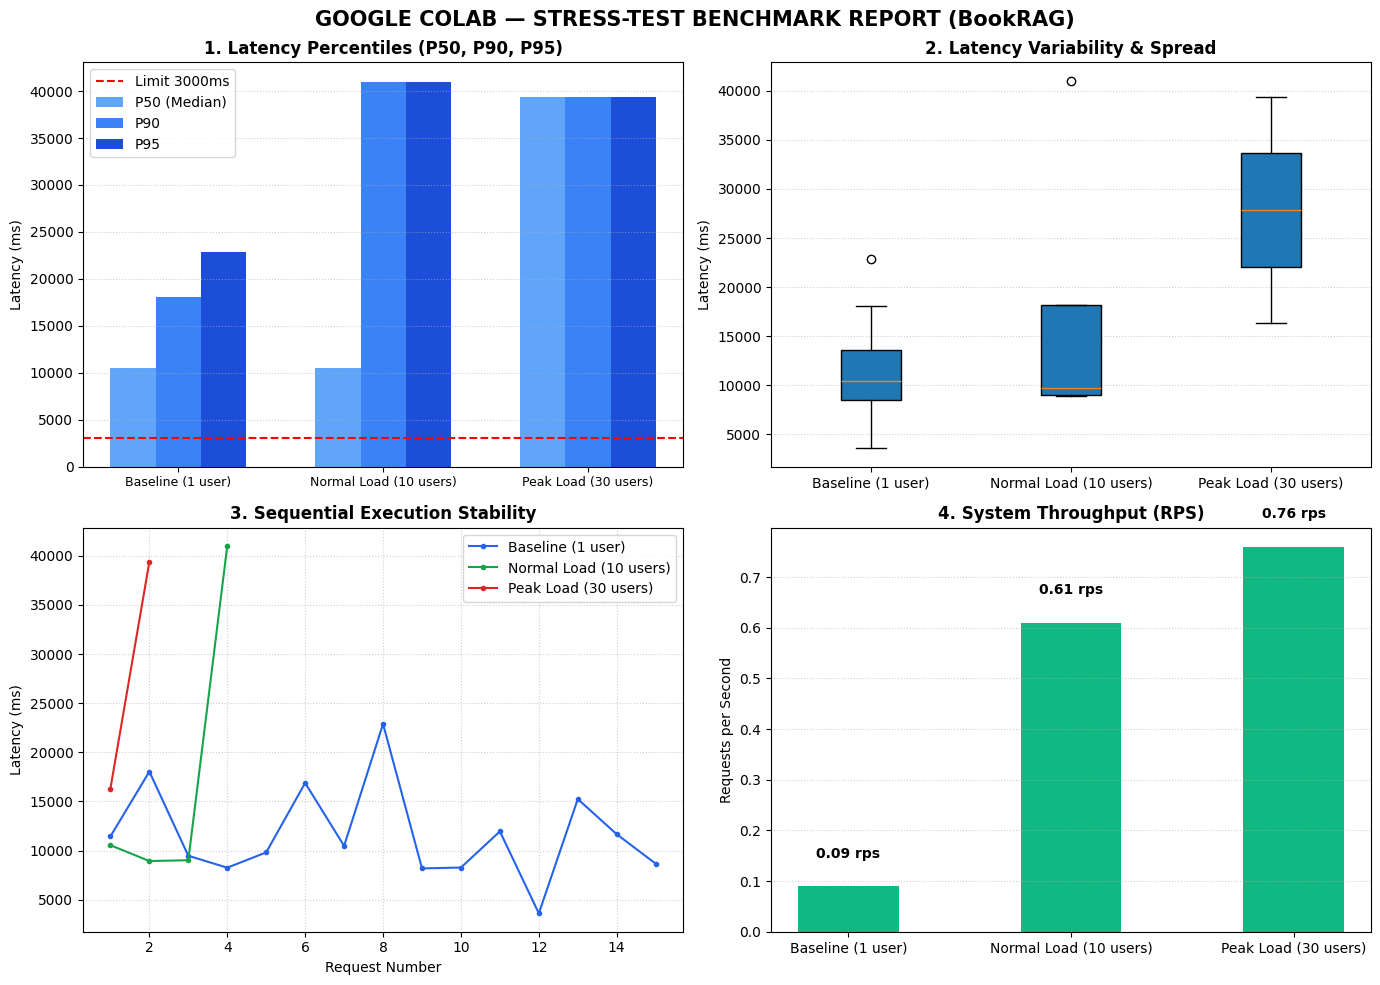

📈 Đã vẽ và lưu đồ thị: colab_stress_test_report.png


In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("GOOGLE COLAB — STRESS-TEST BENCHMARK REPORT (BookRAG)", fontsize=15, fontweight='bold', y=0.98)

scenarios = list(summary_stats.keys())
x = range(len(scenarios))
w = 0.22

# 1. Percentiles
ax1 = axes[0, 0]
p50_v = [summary_stats[s]["p50_ms"] for s in scenarios]
p90_v = [summary_stats[s]["p90_ms"] for s in scenarios]
p95_v = [summary_stats[s]["p95_ms"] for s in scenarios]
ax1.bar([i - w for i in x], p50_v, w, label='P50 (Median)', color='#60a5fa')
ax1.bar(x, p90_v, w, label='P90', color='#3b82f6')
ax1.bar([i + w for i in x], p95_v, w, label='P95', color='#1d4ed8')
ax1.axhline(y=3000, color='red', linestyle='--', label='Limit 3000ms')
ax1.set_title("1. Latency Percentiles (P50, P90, P95)", fontweight='bold')
ax1.set_ylabel("Latency (ms)")
ax1.set_xticks(list(x))
ax1.set_xticklabels(scenarios, fontsize=9)
ax1.legend()
ax1.grid(axis='y', linestyle=':', alpha=0.6)

# 2. Boxplot
ax2 = axes[0, 1]
box_data = [[r["latency_ms"] for r in raw_results[s] if r["success"]] for s in scenarios]
ax2.boxplot(box_data, tick_labels=scenarios, patch_artist=True)
ax2.set_title("2. Latency Variability & Spread", fontweight='bold')
ax2.set_ylabel("Latency (ms)")
ax2.grid(axis='y', linestyle=':', alpha=0.6)

# 3. Timeline
ax3 = axes[1, 0]
colors = ['#2563eb', '#16a34a', '#dc2626']
for s, c in zip(scenarios, colors):
    lats = [r["latency_ms"] for r in raw_results[s] if r["success"]]
    ax3.plot(range(1, len(lats) + 1), lats, marker='o', markersize=3, label=s, color=c)
ax3.set_title("3. Sequential Execution Stability", fontweight='bold')
ax3.set_xlabel("Request Number")
ax3.set_ylabel("Latency (ms)")
ax3.legend()
ax3.grid(True, linestyle=':', alpha=0.6)

# 4. Throughput (RPS)
ax4 = axes[1, 1]
rps_v = [summary_stats[s]["rps"] for s in scenarios]
bars = ax4.bar(scenarios, rps_v, color='#10b981', width=0.45)
for b in bars:
    ax4.text(b.get_x() + b.get_width()/2., b.get_height() + 0.05, f"{b.get_height():.2f} rps", ha='center', va='bottom', fontweight='bold')
ax4.set_title("4. System Throughput (RPS)", fontweight='bold')
ax4.set_ylabel("Requests per Second")
ax4.grid(axis='y', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig("colab_stress_test_report.png", dpi=200)
plt.show()
print("📈 Đã vẽ và lưu đồ thị: colab_stress_test_report.png")

### 📌 Bước 6: Xuất Bảng Thống Kê Định Lượng (DataFrame Table)

In [7]:
df_report = pd.DataFrame.from_dict(summary_stats, orient='index')
df_report.rename(columns={
    'concurrency': 'Tải (users)',
    'requests': 'Số request',
    'rps': 'Thông lượng (RPS)',
    'error_rate': 'Tỷ lệ lỗi (%)',
    'mean_ms': 'Độ trễ TB (ms)',
    'p50_ms': 'P50 (ms)',
    'p95_ms': 'P95 (ms)',
    'target_p95': 'Mục tiêu P95 (ms)',
    'passed': 'Đạt chuẩn'
}, inplace=True)

display(df_report)
df_report.to_csv("colab_stress_test_summary.csv", encoding="utf-8-sig")
print("📁 Đã xuất dữ liệu bảng tóm tắt: colab_stress_test_summary.csv")

,Tải (users),Số request,duration_s,Thông lượng (RPS),Tỷ lệ lỗi (%),Độ trễ TB (ms),P50 (ms),p90_ms,P95 (ms),Mục tiêu P95 (ms),Đạt chuẩn
Baseline (1 user),1,15,174.88,0.09,0.00,11658.8,10475.28,18040.44,22894.56,1800.0,False
Normal Load (10 users),10,25,41.07,0.61,84.00,17378.3,10546.67,41012.23,41012.23,2500.0,False
Peak Load (30 users),30,30,39.42,0.76,93.33,27851.1,39392.62,39392.62,39392.62,3000.0,False


📁 Đã xuất dữ liệu bảng tóm tắt: colab_stress_test_summary.csv
